In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 18.2 MB/s eta 0:00:00


In [3]:
import os
import gc
import ast
import ast
import pywt
import copy
import torch
import joblib
import tempfile
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import tensorflow as tf
from tqdm.auto import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']


path='/content/drive/Shareddrives/XAI Project Shared Drive'
X = np.load(f'{path}/X_100hz.npy')
df_ptbxl = pd.read_csv(f'{path}/ptbxl_processed_metadata.csv', index_col='ecg_id')
df_ptbxl['scp_codes'] = df_ptbxl['scp_codes'].apply(lambda x: ast.literal_eval(x))

print(f"Signal Data Shape [Samples, Time, Leads]: {X.shape}")
print(f"Metadata Shape: {df_ptbxl.shape}")


Signal Data Shape [Samples, Time, Leads]: (21799, 1000, 12)
Metadata Shape: (21799, 27)


In [4]:
agg_df = pd.read_csv(f'{path}/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dict):
    tmp = []
    for key in y_dict.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

df_ptbxl['diagnostic_superclass'] = df_ptbxl.scp_codes.apply(aggregate_diagnostic)


superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for sc in superclasses:
    df_ptbxl[sc] = df_ptbxl['diagnostic_superclass'].apply(lambda x: 1 if sc in x else 0)

print("\nSample of Superclass Targets:")
display(df_ptbxl[['diagnostic_superclass'] + superclasses].head())


Sample of Superclass Targets:


,diagnostic_superclass,NORM,MI,STTC,CD,HYP
ecg_id,,,,,,
1,[NORM],1,0,0,0,0
2,[NORM],1,0,0,0,0
3,[NORM],1,0,0,0,0
4,[NORM],1,0,0,0,0
5,[NORM],1,0,0,0,0


Extracting Heartbeats (Pan-Tompkins):   0%|          | 0/21799 [00:00<?, ?it/s]


Original PTB-XL Shape: (21799, 1000, 12)
Segmented Beats Shape: (261012, 12, 60) (Matches Paper's 0.6s / 60-sample length)
Labels Shape: (261012, 5)


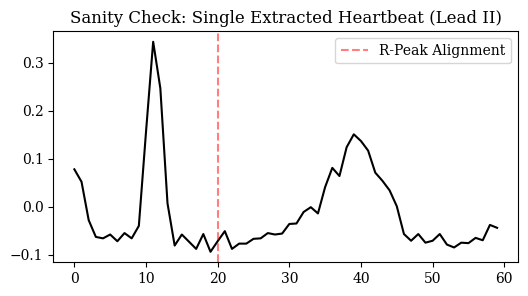

In [ ]:
import neurokit2 as nk
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


FS = 100
PRE_SAMPLES = int((200 / 1000) * FS) 
POST_SAMPLES = int((400 / 1000) * FS) 
SEGMENT_LENGTH = PRE_SAMPLES + POST_SAMPLES 

X_beats = []
y_beats = []

LEAD_FOR_PEAKS = 1

Y = df_ptbxl[superclasses].values

for i in tqdm(range(len(X)), desc="Extracting Heartbeats (Pan-Tompkins)"):
    lead_ii = X[i, :, LEAD_FOR_PEAKS]

    try:
        # Clean the signal and find R-peaks using Pan-Tompkins '85
        cleaned_ecg = nk.ecg_clean(lead_ii, sampling_rate=FS, method="pantompkins1985")
        _, info = nk.ecg_peaks(cleaned_ecg, sampling_rate=FS, method="pantompkins1985")
        r_peaks = info["ECG_R_Peaks"]

        # 3. Slice all 12 leads around each valid R-peak
        for peak in r_peaks:
            # Ensure the window doesn't go out of bounds of the 10-second strip
            if peak - PRE_SAMPLES >= 0 and peak + POST_SAMPLES < X.shape[1]:

                # Extract the 0.6s segment for all 12 leads [Time, Leads]
                beat_segment = X[i, peak - PRE_SAMPLES : peak + POST_SAMPLES, :]

                X_beats.append(beat_segment)
                y_beats.append(Y[i]) # Inherit the 10-second label for this beat

    except Exception as e:
        # Skip signals that are too corrupted for the algorithm to find peaks
        continue

# Convert to Numpy Arrays
X_beats = np.array(X_beats)
y_beats = np.array(y_beats)

# Transpose for PyTorch CNN: [Samples, Time, Leads] -> [Samples, Leads, Time]
X_beats_transposed = np.transpose(X_beats, (0, 2, 1))

print(f"\nOriginal PTB-XL Shape: {X.shape}")
print(f"Segmented Beats Shape: {X_beats_transposed.shape} (Matches Paper's 0.6s / 60-sample length)")
print(f"Labels Shape: {y_beats.shape}")

# Plot a quick sanity check of the first extracted beat (Lead II)
plt.figure(figsize=(6,3))
plt.plot(X_beats[0, :, LEAD_FOR_PEAKS], color='black')
plt.axvline(x=PRE_SAMPLES, color='red', linestyle='--', alpha=0.5, label='R-Peak Alignment')
plt.title("Sanity Check: Single Extracted Heartbeat (Lead II)")
plt.legend()
plt.show()

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_temp, X_test, y_temp, y_test = train_test_split(X_beats_transposed, y_beats, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=42)

batch_size = 256

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
class MultiLabelFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(MultiLabelFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce_with_logits(inputs, targets)
        pt = torch.exp(-bce_loss)  # pt is the probability of the true class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, path='best_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

In [ ]:
class ECG_CNN(nn.Module):
    def __init__(self, num_classes=5, num_leads=12):
        super(ECG_CNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(in_channels=num_leads, out_channels=64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )

        self.flatten = nn.Flatten()

        flattened_size = 16 * 7

        self.dense_block = nn.Sequential(
            nn.Linear(flattened_size, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.flatten(x)
        x = self.dense_block(x)
        return x

model = ECG_CNN(num_classes=5, num_leads=12).to(device)
print(model)

ECG_CNN(
  (conv_block1): Sequential(
    (0): Conv1d(12, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
  )
  (conv_block3): Sequential(
    (0): Conv1d(32, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense_block): Sequential(
    (0): Linear(in_features=112, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
 

In [9]:
model_save_path = f'{path}/best_ecg_cnn_model3.pth'

In [ ]:
epochs = 100
learning_rate = 0.001

criterion = MultiLabelFocalLoss(alpha=0.25, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=7, path=model_save_path)

train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    for inputs, targets in train_bar:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
    with torch.no_grad():
        for inputs, targets in val_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_val_loss += loss.item()
            val_bar.set_postfix(loss=loss.item())

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Early Stopping check
    early_stopping(avg_val_loss, model)
    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}. Best model saved to {model_save_path}")
        break

Epoch 1/100 [Train]:   0%|          | 0/816 [00:00<?, ?it/s]

Epoch 1/100 [Val]:   0%|          | 0/102 [00:00<?, ?it/s]

Epoch 1/100 | Train Loss: 0.0285 | Val Loss: 0.0237


Epoch 2/100 [Train]:   0%|          | 0/816 [00:00<?, ?it/s]

Epoch 2/100 [Val]:   0%|          | 0/102 [00:00<?, ?it/s]

...

Epoch 76/100 [Val]:   0%|          | 0/102 [00:00<?, ?it/s]

Epoch 76/100 | Train Loss: 0.0189 | Val Loss: 0.0177


Epoch 77/100 [Train]:   0%|          | 0/816 [00:00<?, ?it/s]

Epoch 77/100 [Val]:   0%|          | 0/102 [00:00<?, ?it/s]

Epoch 77/100 | Train Loss: 0.0189 | Val Loss: 0.0177
Early stopping triggered at epoch 77. Best model saved to /content/drive/Shareddrives/XAI Project Shared Drive/best_ecg_cnn_model3.pth


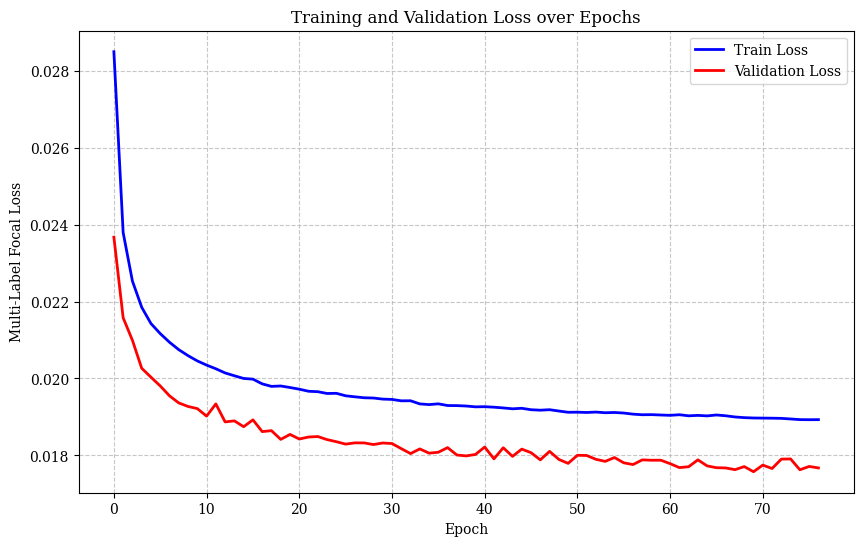

Confirmed: Model successfully saved to /content/drive/Shareddrives/XAI Project Shared Drive/best_ecg_cnn_model3.pth


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='red', linewidth=2)
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Multi-Label Focal Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

import os
if os.path.exists(model_save_path):
    print(f"Confirmed: Model successfully saved to {model_save_path}")

In [ ]:
model = ECG_CNN(num_classes=5, num_leads=12).to(device)
model.load_state_dict(torch.load(model_save_path))
model.eval()

ECG_CNN(
  (conv_block1): Sequential(
    (0): Conv1d(12, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
  )
  (conv_block3): Sequential(
    (0): Conv1d(32, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
  )
  (adaptive_pool): AdaptiveAvgPool1d(output_size=16)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense_block): Sequential(
    (0): Linear(in_features=256, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_featu

In [23]:
!pip install captum

from captum.attr import DeepLift, GradientShap
import matplotlib.colors as mcolors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 16.4 MB/s eta 0:00:00


In [ ]:
def plot_saliency_map(signal, attributions, lead_idx=0, title="Saliency Map", class_name=""):
    """
    Plots the ECG signal for a specific lead with the attribution values
    overlayed as a background color map (red = important for prediction).
    """
    sig = signal[0, lead_idx, :].cpu().detach().numpy()
    attr = attributions[0, lead_idx, :].cpu().detach().numpy()

    attr_norm = attr / np.max(np.abs(attr) + 1e-10)

    fig, ax = plt.subplots(figsize=(12, 4))


    time = np.arange(len(sig)) / 100.0

    extent = [time[0], time[-1], np.min(sig) - 0.5, np.max(sig) + 0.5]
    im = ax.imshow(attr_norm[np.newaxis, :], aspect='auto', cmap='coolwarm',
                   extent=extent, alpha=0.5, vmin=-1, vmax=1)

    ax.plot(time, sig, color='black', linewidth=1.5)

    ax.set_title(f'{title} - Explaining class: {class_name} (Lead {lead_idx})')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Normalized Voltage')


    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label('Importance (Red = Positive, Blue = Negative)')

    plt.tight_layout()
    plt.show()

Model Probabilities vs True Targets:
NORM: True=0, Predicted_Prob=0.3385
MI: True=1, Predicted_Prob=0.6530
STTC: True=0, Predicted_Prob=0.1841
CD: True=0, Predicted_Prob=0.2897
HYP: True=0, Predicted_Prob=0.1503

Generating explanations for: MI
Running DeepLIFT...
Running Gradient SHAP...


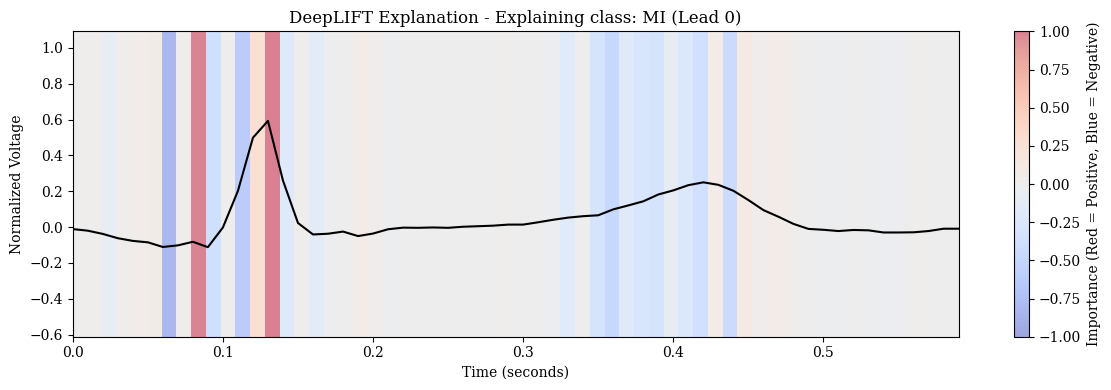

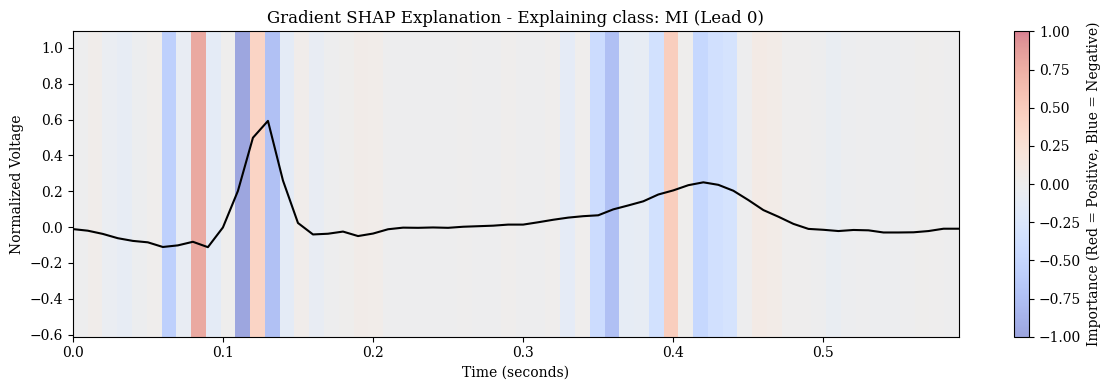

In [ ]:
model.eval()
sample_idx = 17 # Change this to explore different ECGs
inputs, targets = test_dataset[sample_idx]
inputs = inputs.unsqueeze(0).to(device) # Add batch dimension: [1, 12, Length]

# Run prediction to see what the model thinks
with torch.no_grad():
    logits = model(inputs)
    probs = torch.sigmoid(logits).cpu().numpy()[0]

print("Model Probabilities vs True Targets:")
for i, sc_name in enumerate(superclasses):
    print(f"{sc_name}: True={int(targets[i].item())}, Predicted_Prob={probs[i]:.4f}")

# Select the class index we want to explain (e.g., the one with the highest predicted probability)
target_class_idx = int(np.argmax(probs)) # Convert numpy.int64 to Python int
target_class_name = superclasses[target_class_idx]
print(f"\nGenerating explanations for: {target_class_name}")

# 2. Define the baseline (a neutral ECG signal, usually a tensor of zeros)
baseline = torch.zeros_like(inputs).to(device)

# --- DEEPLIFT ---
print("Running DeepLIFT...")
dl = DeepLift(model)
# Note: target specifies which output neuron to explain
attr_dl = dl.attribute(inputs, baselines=baseline, target=target_class_idx)

# --- GRADIENT SHAP ---
print("Running Gradient SHAP...")
gs = GradientShap(model)
# Gradient SHAP takes a distribution of baselines. We provide a batch of zeros with some random noise.
baselines_dist = torch.randn(10, inputs.shape[1], inputs.shape[2]).to(device) * 0.001
attr_gs = gs.attribute(inputs, baselines=baselines_dist, target=target_class_idx)

# 3. Plot the results (Looking at Lead 0, usually Lead I)
lead_to_plot = 0

plot_saliency_map(inputs, attr_dl, lead_idx=lead_to_plot,
                  title="DeepLIFT Explanation", class_name=target_class_name)

plot_saliency_map(inputs, attr_gs, lead_idx=lead_to_plot,
                  title="Gradient SHAP Explanation", class_name=target_class_name)

In [14]:
!pip install shap

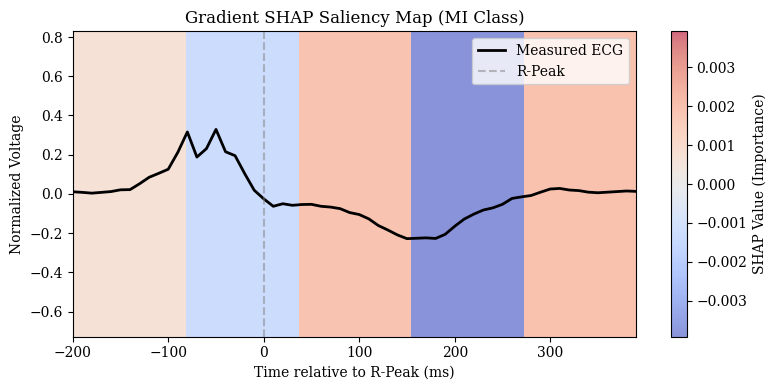

In [19]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Select a True Positive MI beat
mi_class_idx = 1
mi_indices = np.where(y_test[:, mi_class_idx] == 1)[0]
sample_idx = mi_indices[0]

# Shape is now: [1, 12, 60]
sample_x_np = X_test[sample_idx:sample_idx+1]
sample_x_tensor = torch.tensor(sample_x_np, dtype=torch.float32).to(device)

# 2. Get background data from the NEW segmented training set
# Shape is now: [100, 12, 60]
background_tensor = torch.tensor(X_train[:100], dtype=torch.float32).to(device)

# 3. Run the Gradient Explainer
model.eval()
grad_explainer = shap.GradientExplainer(model, background_tensor)
grad_shap_values = grad_explainer.shap_values(sample_x_tensor)

# Extract values for the MI class [Lead, Time] -> [12, 60]
mi_grad_shap = grad_shap_values[0, mi_class_idx] # Corrected indexing

# 4. Updated Visualization Function (Tuned for 0.6s beats)
def plot_beat_saliency(signal, shap_vals, lead_idx, title):
    lead_signal = signal[lead_idx]
    lead_shap = shap_vals[lead_idx]

    # Create an X-axis in milliseconds (-200ms to +400ms)
    # 60 samples at 100Hz = 10ms per sample
    time_ms = np.linspace(-200, 400, len(lead_signal), endpoint=False)

    fig, ax = plt.subplots(figsize=(8, 4)) # Slightly narrower for a single beat

    # Plot the ECG waveform
    ax.plot(time_ms, lead_signal, color='black', linewidth=2, label='Measured ECG')

    # Mark the R-peak alignment (Time = 0)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='R-Peak')

    # Normalize colormap symmetrically around 0
    vmax = max(np.abs(lead_shap).max(), 1e-5)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0., vmax=vmax)

    # Plot SHAP values as a heatmap overlay
    extent = [time_ms[0], time_ms[-1], lead_signal.min() - 0.5, lead_signal.max() + 0.5]
    im = ax.imshow(lead_shap[np.newaxis, :], cmap='coolwarm', aspect='auto', extent=extent, norm=norm, alpha=0.6)

    fig.colorbar(im, ax=ax, label='SHAP Value (Importance)')
    ax.set_title(title)
    ax.set_xlabel('Time relative to R-Peak (ms)')
    ax.set_ylabel('Normalized Voltage')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Plot Lead V2 (index 7) or adjust as needed
plot_lead_idx = 7
plot_beat_saliency(sample_x_np[0], mi_grad_shap, plot_lead_idx, 'Gradient SHAP Saliency Map (MI Class)')

In [ ]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Select a True Positive MI sample (Index 1 in our superclasses)
mi_class_idx = 1
mi_indices = np.where(y_test[:, mi_class_idx] == 1)[0]
sample_idx = mi_indices[0]

sample_x_np = X_test[sample_idx:sample_idx+1] # Shape: [1, 12, time_steps]
sample_x_tensor = torch.tensor(sample_x_np, dtype=torch.float32).to(device)

# 2. Define Background datasets
background_tensor = torch.tensor(X_train[:100], dtype=torch.float32).to(device)
# Numpy arrays (flattened) for Kernel/Permutation
background_np_flat = X_train[:10].reshape(10, -1)
sample_x_flat = sample_x_np.reshape(1, -1)

# 3. Visualization Function (Matches the paper's saliency map style)
def plot_ecg_saliency(signal, shap_vals, lead_idx, title):
    lead_signal = signal[lead_idx]
    lead_shap = shap_vals[lead_idx]
    time_steps = np.arange(len(lead_signal))

    fig, ax = plt.subplots(figsize=(12, 4))

    # Plot the ECG waveform
    ax.plot(time_steps, lead_signal, color='black', linewidth=1.5, label='Measured ECG')

    # Normalize colormap symmetrically around 0
    vmax = max(np.abs(lead_shap).max(), 1e-5)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0., vmax=vmax)

    # Plot SHAP values as a heatmap overlay
    extent = [time_steps[0], time_steps[-1], lead_signal.min() - 0.5, lead_signal.max() + 0.5]
    im = ax.imshow(lead_shap[np.newaxis, :], cmap='coolwarm', aspect='auto', extent=extent, norm=norm, alpha=0.5)

    fig.colorbar(im, ax=ax, label='SHAP Value')
    ax.set_title(title)
    ax.set_xlabel('Time (samples)')
    ax.set_ylabel('Normalized Voltage')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# We will plot Lead V2 (index 7) for all examples, as it's useful for anterior MI
plot_lead_idx = 7

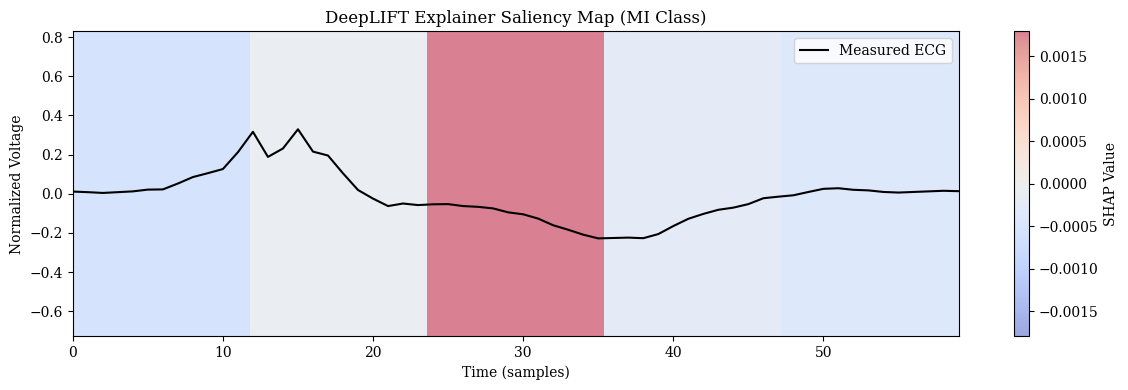

In [21]:
model.eval()

# Initialize the Deep Explainer
deep_explainer = shap.DeepExplainer(model, background_tensor)

# Calculate SHAP values
deep_shap_values = deep_explainer.shap_values(sample_x_tensor)

# Extract values for the MI class and plot
# shap_values is a list where each element corresponds to a class
mi_deep_shap = deep_shap_values[0, mi_class_idx]

plot_ecg_saliency(sample_x_np[0], mi_deep_shap, plot_lead_idx, 'DeepLIFT Explainer Saliency Map (MI Class)')

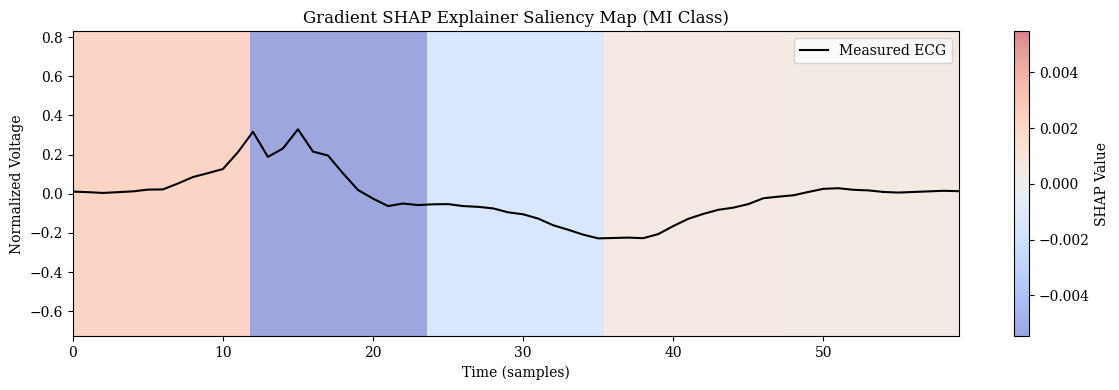

In [22]:
# Initialize Gradient Explainer
grad_explainer = shap.GradientExplainer(model, background_tensor)

# Calculate SHAP values
grad_shap_values = grad_explainer.shap_values(sample_x_tensor)

# Extract and plot
mi_grad_shap = grad_shap_values[0, mi_class_idx]
plot_ecg_saliency(sample_x_np[0], mi_grad_shap, plot_lead_idx, 'Gradient SHAP Explainer Saliency Map (MI Class)')

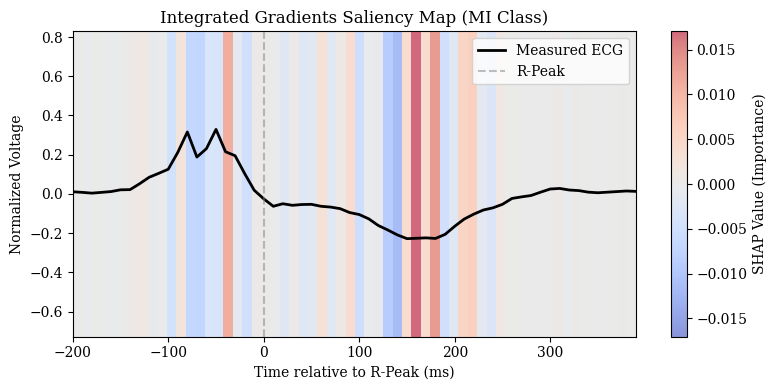

In [35]:
from captum.attr import IntegratedGradients
import torch

# 1. Initialize Integrated Gradients with your trained model
ig = IntegratedGradients(model)

# 2. Define a baseline (a flat line/zeros of the exact same shape as your input)
# Shape: [1, 12, 60]
baseline = torch.zeros_like(sample_x_tensor).to(device)

# 3. Calculate the attributions (importance scores) for the MI class
# target=1 corresponds to the MI class index
model.eval()
attributions, convergence_delta = ig.attribute(
    inputs=sample_x_tensor,
    baselines=baseline,
    target=mi_class_idx,
    return_convergence_delta=True
)

# 4. Extract the values and convert to numpy for plotting
# attributions shape matches input: [1, 12, 60]
mi_ig_values = attributions[0].cpu().detach().numpy()
sample_signal_np = sample_x_tensor[0].cpu().numpy()

# 5. Plot using the exact same function we defined in Cell 6!
plot_beat_saliency(
    signal=sample_signal_np,
    shap_vals=mi_ig_values,
    lead_idx=plot_lead_idx, # Lead V2
    title='Integrated Gradients Saliency Map (MI Class)'
)

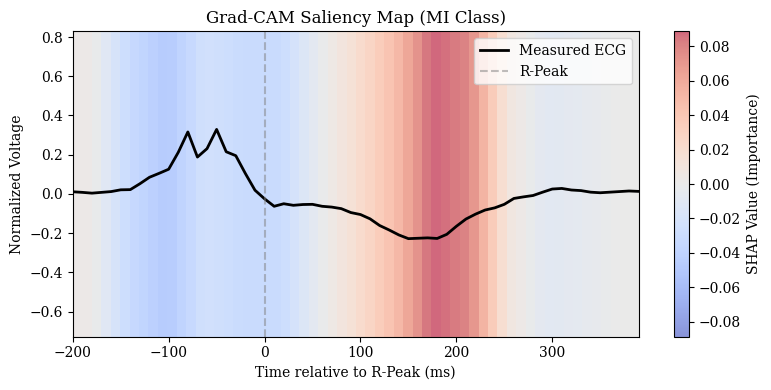

In [38]:
from captum.attr import LayerGradCam, LayerAttribution
import torch.nn.functional as F

model.eval()

# 1. Target the final Convolutional Layer
# In our ECG_Beat_CNN, this is the Conv1d layer inside conv_block3
target_layer = model.conv_block3[0]

# 2. Initialize LayerGradCam
layer_gc = LayerGradCam(model, target_layer)

# 3. Calculate Attribution for the MI class
# Output shape will match the spatial dimension of the target layer (Time: 8)
gc_attr = layer_gc.attribute(sample_x_tensor, target=mi_class_idx)

# 4. Upsample the coarse map (Length 8) back to our original input resolution (Length 60)
upsampled_gc_attr = LayerAttribution.interpolate(gc_attr, (60,), interpolate_mode='linear')

# Extract the numpy array: Shape [1, 1, 60] -> [60]
time_importance = upsampled_gc_attr[0, 0].cpu().detach().numpy()

# 5. Broadcast this 1D time importance across all 12 leads so our plotting function can read it
# Shape becomes [12, 60]
mi_gradcam_values = np.tile(time_importance, (12, 1))

# 6. Plot using the shared visualization function
plot_beat_saliency(
    signal=sample_x_np[0],
    shap_vals=mi_gradcam_values,
    lead_idx=plot_lead_idx,
    title='Grad-CAM Saliency Map (MI Class)'
)

In [40]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ccabd797490ab2ab1dca6f4b6154d54ce5f4df9a525a4dcfae3f1639719944fd
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Running LIME... Perturbing inputs and training local surrogate model.


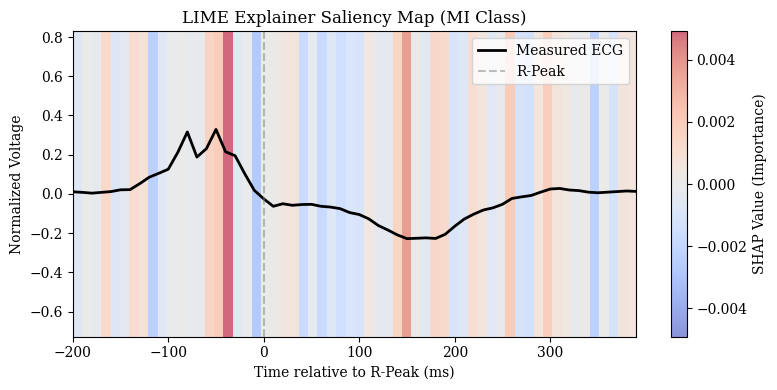

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# 1. Prepare flat background data (used by LIME to understand feature distributions)
# We use the segmented training data from the Pan-Tompkins update
background_np_flat = X_train[:100].reshape(100, -1)
sample_x_flat = sample_x_np.reshape(-1) # Shape: [720] (12 leads * 60 time steps)

# 2. Create a wrapper function that LIME can call
def lime_predict_wrapper(flat_inputs):
    # LIME gives us a flat numpy array [batch, 720]
    # We must reshape it back to [batch, 12, 60] for our CNN
    reshaped_inputs = flat_inputs.reshape(-1, 12, 60)
    tensor_inputs = torch.tensor(reshaped_inputs, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(tensor_inputs)
        # LIME expects probabilities (0 to 1) for all classes, so we apply Sigmoid
        probs = torch.sigmoid(logits).cpu().numpy()

    return probs

# 3. Initialize the LIME Explainer
explainer = LimeTabularExplainer(
    training_data=background_np_flat,
    mode='classification',
    training_labels=y_train[:100],
    feature_names=[f'lead_{l}_time_{t}' for l in range(12) for t in range(60)],
    discretize_continuous=False # Keep the ECG signal continuous
)

# 4. Generate the explanation for our specific MI sample
print("Running LIME... Perturbing inputs and training local surrogate model.")
lime_exp = explainer.explain_instance(
    data_row=sample_x_flat,
    predict_fn=lime_predict_wrapper,
    labels=(mi_class_idx,), # We only care about explaining the MI class
    num_features=720, # Ask it to score all 720 data points
    num_samples=1000  # Number of perturbed samples to generate
)
# 5. Extract the feature importance scores for the MI class
lime_scores = np.zeros(720)
for idx_str, score in lime_exp.local_exp[mi_class_idx]:
    lime_scores[int(idx_str)] = score

mi_lime_values = lime_scores.reshape(12, 60)

# 6. Plot using the shared visualization function
plot_beat_saliency(
    signal=sample_x_np[0],
    shap_vals=mi_lime_values,
    lead_idx=plot_lead_idx,
    title='LIME Explainer Saliency Map (MI Class)'
)

Extracting internal model representations...
Running t-SNE (This takes 10-30 seconds)...


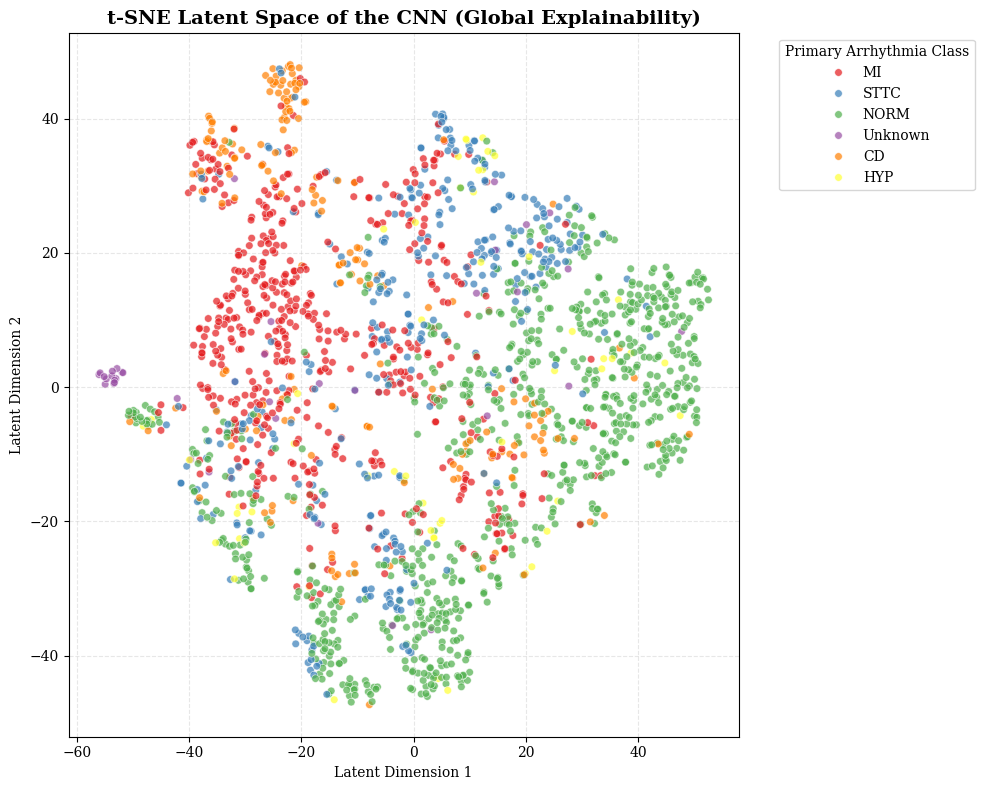

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def get_embeddings(model, data_loader, num_samples=1500):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)

            x = model.conv_block1(inputs)
            x = model.conv_block2(x)
            x = model.conv_block3(x)
            emb = model.flatten(x)

            embeddings.append(emb.cpu().numpy())
            labels.append(targets.numpy())

            if len(np.vstack(embeddings)) >= num_samples:
                break

    return np.vstack(embeddings)[:num_samples], np.vstack(labels)[:num_samples]

print("Extracting internal model representations...")
emb_matrix, target_matrix = get_embeddings(model, test_loader, num_samples=2000)

print("Running t-SNE (This takes 10-30 seconds)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(emb_matrix)

superclass_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
plot_labels = []

for row in target_matrix:
    active_classes = np.where(row == 1)[0]
    if len(active_classes) > 0:
        plot_labels.append(superclass_names[active_classes[0]])
    else:
        plot_labels.append("Unknown")

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=emb_2d[:, 0],
    y=emb_2d[:, 1],
    hue=plot_labels,
    palette='Set1',
    s=30, # dot size
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title("t-SNE Latent Space of the CNN (Global Explainability)", fontsize=14, fontweight='bold')
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.legend(title='Primary Arrhythmia Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

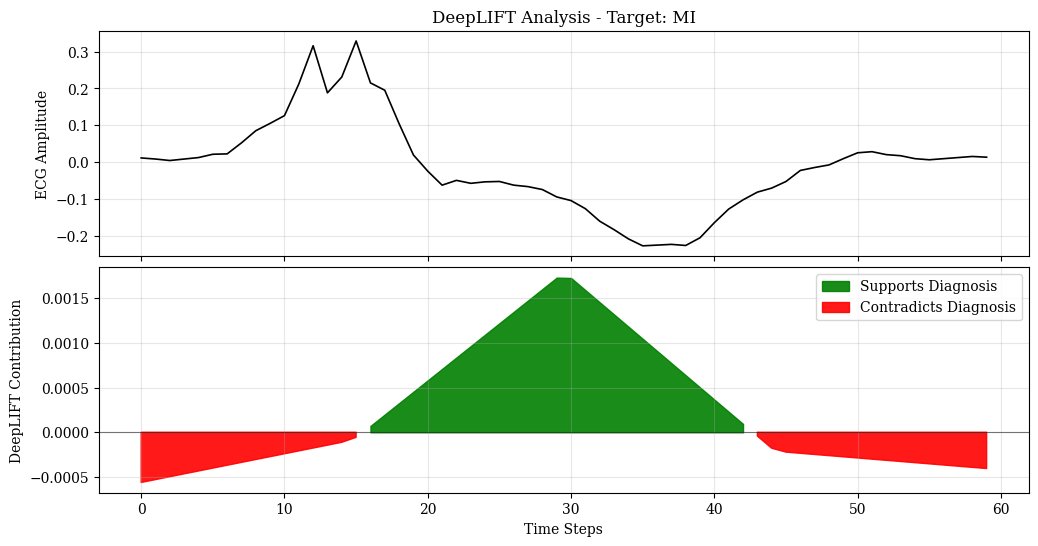

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_deeplift_stacked(signal, shap_vals, lead_idx, title="DeepLIFT Analysis - Target: MI"):
    # Extract the specific lead
    lead_signal = signal[lead_idx]
    lead_shap_raw = shap_vals[lead_idx]
    time_steps = np.arange(len(lead_signal))

    if len(lead_shap_raw) != len(lead_signal):
        original_indices = np.linspace(0, len(lead_shap_raw) - 1, num=len(lead_shap_raw))
        new_indices = np.linspace(0, len(lead_shap_raw) - 1, num=len(lead_signal))
        lead_shap = np.interp(new_indices, original_indices, lead_shap_raw)
    else:
        lead_shap = lead_shap_raw

    # Create a figure with 2 vertically stacked subplots that share the X-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [1, 1]})

    # --- Top Panel: Raw ECG Signal ---
    ax1.plot(time_steps, lead_signal, color='black', linewidth=1.2)
    ax1.set_title(title, fontsize=12)
    ax1.set_ylabel('ECG Amplitude')
    ax1.grid(True, alpha=0.3)

    # --- Bottom Panel: DeepLIFT Contributions ---
    # Draw a baseline at 0
    ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)

    # Fill positive contributions in green
    ax2.fill_between(time_steps, 0, lead_shap, where=(lead_shap > 0),
                     color='green', alpha=0.9, label='Supports Diagnosis')

    # Fill negative contributions in red
    ax2.fill_between(time_steps, 0, lead_shap, where=(lead_shap < 0),
                     color='red', alpha=0.9, label='Contradicts Diagnosis')

    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('DeepLIFT Contribution')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    # Adjust layout to remove space between the plots
    plt.subplots_adjust(hspace=0.05)
    plt.show()

plot_deeplift_stacked(
    signal=sample_x_np[0],
    shap_vals=mi_deep_shap,
    lead_idx=plot_lead_idx # e.g., Lead V2 (index 7)
)